# Data Extraction
Connect to the OneDrive and then extract the .DAT files which we want to work with.  
Note that not all of these formats are the same, with some notable exceptions being TAXDATA2021 and Alka_Chopra_ShareFile_TAXDATA2022, which is a download URL.

**Note**: A lot of the code is commented out at the top. This is the code that was originally used to extract the .DAT files from the relevant OneDrive synced folder. Uncomment when running this script the first time and replace COBB_PATH with your relevant path.

In [1]:
import pandas as pd
import os
import shutil
from zipfile import ZipFile
import seaborn as sns

COBB_PATH = "/Users/tpeng/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/AN, Brian's files - County Tax Assessment Data/Cobb - White"
DATA_PATH = "../../data/cobb"

In [ ]:
# Test, do not uncomment
# testzip = ZipFile(os.path.join(COBB_PATH, "TAXDATA2021.zip"))
# testzip.printdir()

# testzip2 = ZipFile(os.path.join(COBB_PATH, "Alka_Chopra_TAXDATA2013.zip"))
# testzip2.printdir()

# testzip3 = ZipFile(os.path.join(COBB_PATH, "Alka_Chopra_TAXDATA2012.zip"))
# testzip3.printdir()

In [ ]:
# First time extraction code only
# zip2000 = ZipFile(os.path.join(COBB_PATH, f"Alka_Chopra_TAXDATA2000.zip"))
# zip2000.extract(f"TAXDATA2000/residential2000/SALES.DAT", DATA_PATH)
# os.rename(os.path.join(DATA_PATH, f"TAXDATA2000/residential2000/SALES.DAT"), os.path.join(DATA_PATH, f"SALES_2000.DAT"))
# shutil.rmtree(os.path.join(DATA_PATH, f"TAXDATA2000"))

In [ ]:
# First time extraction code only
# Extract specifically the Alka_Chopra 2011-2012
# for y in range(2011, 2017):
#     print(y)
#     zip = ZipFile(os.path.join(COBB_PATH, f"Alka_Chopra_TAXDATA{y}.zip"))
#     zip.extract(f"TAXDATA{y}/Residential {y}/SALES.DAT", DATA_PATH)
#     os.rename(os.path.join(DATA_PATH, f"TAXDATA{y}/Residential {y}/SALES.DAT"), os.path.join(DATA_PATH, f"SALES_{y}.DAT"))
#     shutil.rmtree(os.path.join(DATA_PATH, f"TAXDATA{y}"))

In [ ]:
# First time extraction code only
# Extract specifically the Alka_Chopra 2013-2016
# for y in range(2013, 2017):
#     print(y)
#     zip = ZipFile(os.path.join(COBB_PATH, f"Alka_Chopra_TAXDATA{y}.zip"))
#     zip.extract(f"TAXDATA{y}/Residential{y}/SALES.DAT", DATA_PATH)
#     os.rename(os.path.join(DATA_PATH, f"TAXDATA{y}/Residential{y}/SALES.DAT"), os.path.join(DATA_PATH, f"SALES_{y}.DAT"))
#     shutil.rmtree(os.path.join(DATA_PATH, f"TAXDATA{y}"))

In [ ]:
# First time extraction code only
# Extract specifically the TAXDATA 2017-2020 SALES.DAT files
# for y in range(2017, 2021):
#     print(y)
#     zip = ZipFile(os.path.join(COBB_PATH, f"TAXDATA{y}.zip"))
#     zip.extract(f"TAXDATA{y}/Residential{y}/SALES.DAT", DATA_PATH)
#     os.rename(os.path.join(DATA_PATH, f"TAXDATA{y}/Residential{y}/SALES.DAT"), os.path.join(DATA_PATH, f"SALES_{y}.DAT"))
#     shutil.rmtree(os.path.join(DATA_PATH, f"TAXDATA{y}"))

In [ ]:
# First time extraction code only
# zip2021 = ZipFile(os.path.join(COBB_PATH, f"TAXDATA2021.zip"))
# zip2021.extract(f"TAXDATA2021/AssessmentData/Residential2021/SALES.DAT", DATA_PATH)
# os.rename(os.path.join(DATA_PATH, f"TAXDATA2021/AssessmentData/Residential2021/SALES.DAT"), os.path.join(DATA_PATH, f"SALES_2021.DAT"))
# shutil.rmtree(os.path.join(DATA_PATH, f"TAXDATA2021"))

In [ ]:
# Second time data loading code

In [2]:
# 1️ base on Cobb County layout
colspecs = [
    (0,30),   # PARID
    (30,39),  # TRANSNO
    (39,48),  # TRANSDT
    (48,56),  # BOOK
    (56,64),  # PAGE
    (64,73),  # SALEDT
    (73,84),  # PRICE
    (84,85),  # SOURCE
    (85,86),  # SALETYPE
    (86,88),  # SALEVAL
    (88,100)  # FILLER
]

colnames = [
    "PARID", "TRANSNO", "TRANSDT", "BOOK", "PAGE", "SALEDT",
    "PRICE", "SOURCE", "SALETYPE", "SALEVAL", "FILLER"
]

dfs = []

# read .DAT file
for year in ([2000] + list(range(2011, 2020))):
    df = pd.read_fwf(os.path.join(DATA_PATH, f"SALES_{year}.DAT"), colspecs=colspecs, names=colnames)

    # clean data
    # delete filler
    df = df.drop(columns=["FILLER"])

    # Convert date columns to standard format (e.g. 29-MAR-19 → 2019-03-29)
    for col in ["TRANSDT", "SALEDT"]:
        df[col] = pd.to_datetime(df[col], format="%d-%b-%y", errors='coerce')

    # Make sure PRICE is a numeric value
    df["PRICE"] = pd.to_numeric(df["PRICE"], errors='coerce')
    df['YEAR'] = year

    dfs.append(df)

From 2020 Onwards, the .DAT Format Has || Separators Between Columns

In [4]:
# 2020 onwards layout
colspecs = [
    (0,30),   # PARID
    (31,40),  # TRANSNO
    (41,50),  # TRANSDT
    (51,59),  # BOOK
    (60,68),  # PAGE
    (69,78),  # SALEDT
    (79,90),  # PRICE
    (91,92),  # SOURCE
    (93,94),  # SALETYPE
    (95,97),  # SALEVAL
    (97,100)  # FILLER
]

colnames = [
    "PARID", "TRANSNO", "TRANSDT", "BOOK", "PAGE", "SALEDT",
    "PRICE", "SOURCE", "SALETYPE", "SALEVAL", "FILLER"
]

# read .DAT file
for year in range(2020, 2023):
    df = pd.read_fwf(os.path.join(DATA_PATH, f"SALES_{year}.DAT"), colspecs=colspecs, names=colnames)

    # clean data
    # delete filler
    df = df.drop(columns=["FILLER"])

    # Convert date columns to standard format (e.g. 29-MAR-19 → 2019-03-29)
    for col in ["TRANSDT", "SALEDT"]:
        df[col] = pd.to_datetime(df[col], format="%d-%b-%y", errors='coerce')

    # Make sure PRICE is a numeric value
    df["PRICE"] = pd.to_numeric(df["PRICE"], errors='coerce')
    df['YEAR'] = year

    dfs.append(df)

final_df = pd.concat(dfs)
final_df.drop_duplicates(subset=['PARID', 'BOOK', 'PAGE', 'SALEDT'])

,PARID,TRANSNO,TRANSDT,BOOK,PAGE,SALEDT,PRICE,SOURCE,SALETYPE,SALEVAL,YEAR
0,00000000000,NaN,NaT,13311,4148,2000-11-17,110000,6.0,NaN,NaN,2000
1,00000000000,NaN,NaT,13303,4518,2000-10-21,123500,6.0,NaN,NaN,2000
2,00000000000,NaN,NaT,13303,5993,2000-09-29,0,6.0,NaN,NaN,2000
3,00000000000,NaN,NaT,13299,897,2000-09-28,0,6.0,NaN,NaN,2000
4,00000000000,NaN,NaT,13244,239,2000-01-08,84900,6.0,NaN,0.0,2000
...,...,...,...,...,...,...,...,...,...,...,...
854822,TESTSKC,NaN,NaT,NaN,NaN,2019-10-24,1495000,8,2,LP,2022
854823,TESTSKC,NaN,NaT,15212,5850,2015-01-07,800000,6,2,RE,2022
854824,TESTSKC,NaN,NaT,NaN,NaN,2014-11-03,909000,8,2,LP,2022
854825,TESTSKC,NaN,NaT,15140,0490,2014-01-07,0,6,NaN,08,2022


In [59]:
final_df = pd.concat(dfs)
orig_rows = final_df.size

final_df = final_df.drop_duplicates(subset=['PARID', 'SALEDT'])
new_rows = final_df.size

print(f"Rows dropped: {orig_rows - new_rows}")

Rows dropped: 80562031


In [60]:
def correct_date(row):
    if row['SALEDT'].year > (row['YEAR'] + 1):
        return row['SALEDT'] - pd.DateOffset(years=100)
    else:
        return row['SALEDT']

final_df['SALEDT'] = final_df.apply(correct_date, axis=1)

In [61]:
final_df['SALE_YEAR'] = final_df['SALEDT'].dt.year

In [62]:
# Save as a CSV file
final_df.to_csv(os.path.join(DATA_PATH, "out/COBB_SALES_FINAL.csv"), index=False)

In [38]:
print(final_df['SALEDT'].isna().value_counts())
print(final_df['TRANSDT'].isna().value_counts())

SALEDT
False    8088684
Name: count, dtype: int64
TRANSDT
True     8075000
False      13684
Name: count, dtype: int64


In [56]:
grouped_counts = final_df[['SALE_YEAR', 'YEAR']].groupby(by="YEAR").value_counts()
saleyr_by_yr = {}
for (yr, saleyr), count in grouped_counts.items():
    counts = saleyr_by_yr.get(yr, {})
    counts[saleyr] = count
    saleyr_by_yr[yr] = counts

In [57]:
saleyr_yr_df = pd.DataFrame(saleyr_by_yr).sort_index()

Text(0.5, 1.0, 'Sale Year by Year Recorded')

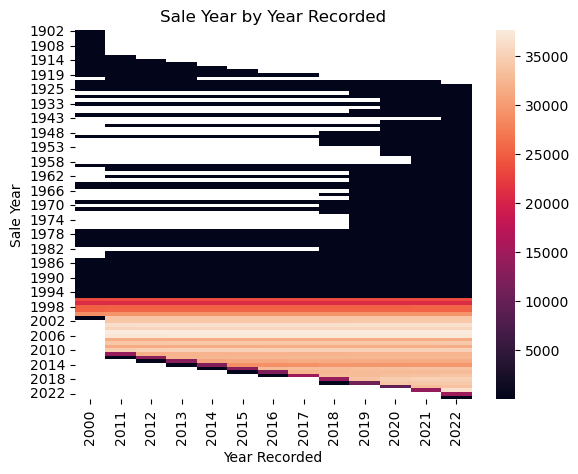

In [58]:
ax = sns.heatmap(saleyr_yr_df)
ax.set_xlabel("Year Recorded")
ax.set_ylabel("Sale Year")
ax.set_title("Sale Year by Year Recorded")

In [ ]:
sns.histplot()

# Merging with Ownership

In [6]:
ownership_df = pd.read_csv(os.path.join(DATA_PATH, f"cobb_digest_full_final.csv"))
sales_df = pd.read_csv(os.path.join(DATA_PATH, f"out/COBB_SALES_FINAL.csv"))

/var/folders/bb/g7vlcgfn14ld8_w41331g0dw0000gn/T/ipykernel_98941/4275464427.py:1: DtypeWarning: Columns (1,7,8,9,14,15,16,22,49,50,63,76,83,84,87,89,90,91,92,93,96,102,103,105,106) have mixed types. Specify dtype option on import or set low_memory=False.
  ownership_df = pd.read_csv(os.path.join(DATA_PATH, f"cobb_digest_full_final.csv"))
/var/folders/bb/g7vlcgfn14ld8_w41331g0dw0000gn/T/ipykernel_98941/4275464427.py:2: DtypeWarning: Columns (0,1,2,3,4,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv(os.path.join(DATA_PATH, f"out/COBB_SALES_FINAL.csv"))


In [12]:
selected_columns = ['parid', 'taxyr', 'propertyaddr', 'grossvalue', 'assessvalue', 'owner1', 'owner2', 'o_addrtype',
                    'o_adrno', 'o_adradd', 'o_adrstr', 'o_adrsuf', 'o_adrsuf2', 'o_cityname', 'o_statecode', 'o_country',
                    'o_postalcode', 'o_unitdesc', 'o_unitno', 'o_addr1', 'o_addr2', 'o_addr3', 'o_zip1', 'o_zip2',
                    'mod_own_adrstr', 'mod_unitno', 'mod_own_adrno', 'o_addr', 'own_corp_flag', 'rental_flag']
selected_columns_x_static = ['taxyr', 'grossvalue', 'assessvalue', 'owner1', 'owner2', 'o_addrtype',
                    'o_adrno', 'o_adradd', 'o_adrstr', 'o_adrsuf', 'o_adrsuf2', 'o_cityname', 'o_statecode', 'o_country',
                    'o_postalcode', 'o_unitdesc', 'o_unitno', 'o_addr1', 'o_addr2', 'o_addr3', 'o_zip1', 'o_zip2',
                    'mod_own_adrstr', 'mod_unitno', 'mod_own_adrno', 'o_addr', 'own_corp_flag', 'rental_flag']
ownership_subset_df = ownership_df.loc[:, selected_columns]

In [7]:
ownership_df['tax_year'].value_counts()

tax_year
2021    270543
2020    269316
2019    267640
2018    261500
2017    258698
2014    257958
2016    257260
2011    256993
2015    255566
2012    253810
2013    251476
Name: count, dtype: int64

In [10]:
sales_df['NEXT_YEAR'] = sales_df['SALE_YEAR'] + 1
original_size = sales_df.shape[0]

# Take subset that is actually contained in the ownership keys
sales_df = sales_df.where((sales_df['SALE_YEAR'] >= 2011) & (sales_df['NEXT_YEAR'] <= 2021))
in_yr_range_size = sales_df.shape[0]

print(f"{in_yr_range_size / original_size * 100}% within the range of 2011 to 2021")

100.0% within the range of 2011 to 2021


In [13]:
merged_left_df = sales_df.merge(ownership_subset_df, how='left', left_on=['PARID', 'SALE_YEAR'], right_on=['parid', 'taxyr'])
merged_left_df = merged_left_df.rename(columns={x: x + "_pre" for x in (selected_columns_x_static)})

merged_left_df = merged_left_df.merge(ownership_subset_df, how='left', left_on=['PARID', 'NEXT_YEAR'], right_on=['parid', 'taxyr'])
merged_left_df = merged_left_df.rename(columns={x: x + "_post" for x in (selected_columns_x_static)})

merged_inner_df = sales_df.merge(ownership_subset_df, left_on=['PARID', 'SALE_YEAR'], right_on=['parid', 'taxyr'])
merged_inner_df = merged_inner_df.rename(columns={x: x + "_pre" for x in (selected_columns_x_static)})

merged_inner_df = merged_inner_df.merge(ownership_subset_df, left_on=['PARID', 'NEXT_YEAR'], right_on=['parid', 'taxyr'])
merged_inner_df = merged_inner_df.rename(columns={x: x + "_post" for x in (selected_columns_x_static)})

In [14]:
merged_left_df.to_csv(os.path.join(DATA_PATH, "out/raw_cobb_merged.csv"))
merged_inner_df.to_csv(os.path.join(DATA_PATH, "out/matched_cobb_merged.csv"))

In [15]:
print(f"{merged_left_df.shape[0] - merged_left_df['parid_x'].isna().sum()} out of {merged_left_df.shape[0]} matched. \n {(merged_left_df.shape[0] - merged_left_df.isna().sum()['parid_x']) * 100 / merged_left_df.shape[0]}% matched sales")

78419 out of 764863 matched. 
 10.252685775099593% matched sales


In [23]:
merged_left_df.where(~merged_left_df['taxyr_pre'].isna())["SALE_YEAR"].value_counts()

SALE_YEAR
2013.0    25125
2014.0    16749
2012.0    15460
2011.0    10861
2015.0     5589
2017.0     1409
2020.0     1005
2018.0      998
2019.0      766
2016.0      457
Name: count, dtype: int64

In [109]:
for key, value in merged_inner_df.isna().sum().items():
    print(key + " " + str(value))

PARID 0
TRANSNO 70794
TRANSDT 74015
BOOK 7077
PAGE 7076
SALEDT 0
PRICE 0
SOURCE 66
SALETYPE 24017
SALEVAL 5108
YEAR 0
SALE_YEAR 0
NEXT_YEAR 0
parid_x 0
taxyr_pre 0
propertyaddr_x 0
grossvalue_pre 0
assessvalue_pre 0
owner1_pre 0
owner2_pre 66710
o_addrtype_pre 0
o_adrno_pre 4259
o_adradd_pre 73791
o_adrstr_pre 4238
o_adrsuf_pre 5772
o_adrsuf2_pre 58790
o_cityname_pre 48
o_statecode_pre 55
o_country_pre 74007
o_postalcode_pre 73993
o_unitdesc_pre 63960
o_unitno_pre 62805
o_addr1_pre 69764
o_addr2_pre 73645
o_addr3_pre 74004
o_zip1_pre 83
o_zip2_pre 66304
mod_own_adrstr_pre 0
mod_unitno_pre 62805
mod_own_adrno_pre 4259
o_addr_pre 0
own_corp_flag_pre 0
rental_flag_pre 0
parid_y 0
taxyr_post 0
propertyaddr_y 0
grossvalue_post 0
assessvalue_post 0
owner1_post 0
owner2_post 67243
o_addrtype_post 0
o_adrno_post 2708
o_adradd_post 73763
o_adrstr_post 2698
o_adrsuf_post 3617
o_adrsuf2_post 52017
o_cityname_post 144
o_statecode_post 159
o_country_post 73960
o_postalcode_post 73921
o_unitdesc_pos

In [114]:
original_rows = merged_inner_df.shape[0]

changed_owners = merged_inner_df.loc[(merged_inner_df['owner1_pre'] != merged_inner_df['owner1_post']) & ~(merged_inner_df['owner1_pre'].isna() & merged_inner_df['owner1_post'].isna()), ['owner1_pre', 'owner1_post']]
changed_rows = changed_owners.shape[0]

print(f"{changed_rows} out of {original_rows} changed owners, \n {changed_rows * 100 / original_rows}%")

43412 out of 74027 changed owners, 
 58.643467923865614%


In [112]:
for key, value in merged_inner_df.isna().sum().items():
    print(key + " " + str(value))

PARID 0
TRANSNO 70794
TRANSDT 74015
BOOK 7077
PAGE 7076
SALEDT 0
PRICE 0
SOURCE 66
SALETYPE 24017
SALEVAL 5108
YEAR 0
SALE_YEAR 0
NEXT_YEAR 0
parid_x 0
taxyr_pre 0
propertyaddr_x 0
grossvalue_pre 0
assessvalue_pre 0
owner1_pre 0
owner2_pre 66710
o_addrtype_pre 0
o_adrno_pre 4259
o_adradd_pre 73791
o_adrstr_pre 4238
o_adrsuf_pre 5772
o_adrsuf2_pre 58790
o_cityname_pre 48
o_statecode_pre 55
o_country_pre 74007
o_postalcode_pre 73993
o_unitdesc_pre 63960
o_unitno_pre 62805
o_addr1_pre 69764
o_addr2_pre 73645
o_addr3_pre 74004
o_zip1_pre 83
o_zip2_pre 66304
mod_own_adrstr_pre 0
mod_unitno_pre 62805
mod_own_adrno_pre 4259
o_addr_pre 0
own_corp_flag_pre 0
rental_flag_pre 0
parid_y 0
taxyr_post 0
propertyaddr_y 0
grossvalue_post 0
assessvalue_post 0
owner1_post 0
owner2_post 67243
o_addrtype_post 0
o_adrno_post 2708
o_adradd_post 73763
o_adrstr_post 2698
o_adrsuf_post 3617
o_adrsuf2_post 52017
o_cityname_post 144
o_statecode_post 159
o_country_post 73960
o_postalcode_post 73921
o_unitdesc_pos

In [121]:
merged_inner_df.loc[(merged_inner_df['own_corp_flag_pre'] == 0) & (merged_inner_df['own_corp_flag_post'] == 1), ['owner1_pre', 'owner1_post']]

,owner1_pre,owner1_post
59,STEFAN MIHAI S,FEDERAL NATIONAL MORTGAGE ASSOC
158,WELLS FARGO BANK NA,BUFFALO PROPERTIES LLC
244,RBC BANK USA,ALL PACE LLC
387,QUANTUM NATIONAL BANK,LOT ONE HOMES INC
388,QUANTUM NATIONAL BANK,LOT ONE HOMES INC
...,...,...
73769,WILSON GINGER,1240 WHITLOCK RIDGE DRIVE LLC
73797,BURCH LUKE & DANIELLE ADAIR,YAMASA CO LTD
73963,CREST LAWN MEMORIAL PARK PRE NEED TRUST,228 PINDOS PLACE LLC
73983,BLOMQUIST BLAKE,PHOENIX CUSTOM BUILDERS LLC


In [123]:
merged_inner_df.loc[(merged_inner_df['own_corp_flag_pre'] == 1) & (merged_inner_df['own_corp_flag_post'] == 0), ['owner1_pre', 'owner1_post']]

,owner1_pre,owner1_post
2,SBATL REAL ESTATE HOLDINGS LLC,DILBECK ERIC
6,RAINTREE HOLDINGS LLC,HENDERSON DAVID R & NORA P
23,DANIEL INVESTMENT GROUP PROPERTIES LLC,RICHARDSON DAVID & SUSAN
42,FEDERAL NATIONAL MORTGAGE ASSOCIATION,BANNISTER JUSTIN H & JULIE
49,SECRETARY HOUSING & URBAN DEVELOPMENT,MCCRACKEN KYIESHA D
...,...,...
73982,PHOENIX CUSTOM BUILIDERS LLC,DIBENEDETTO CHRISTOPHER M & CARISSA C
73985,BLOMQUIST BUILDERS GROUP INC,RAMSEY PATRICK LEE &
73986,BLOMQUIST BUILDERS GROUP INC,RAMSEY PATRICK LEE &
73994,TCP INVESTMENTS LLC,WARD BRIAN LEE


In [122]:
merged_inner_df.loc[(merged_inner_df['own_corp_flag_post'] == 1), ['owner1_pre', 'owner1_post']]

,owner1_pre,owner1_post
0,WIGLEY DEVELOPMENT PARTNERS LLC,WIGLEY DEVELOPMENT PARTNERS LLC
59,STEFAN MIHAI S,FEDERAL NATIONAL MORTGAGE ASSOC
72,MEYER ROBERT L ET AL,MEYER ROBERT L ET AL
85,POINTONE HOLDINGS LP,POINTONE HOLDINGS LP
104,FEDERAL HOME LOAN MORTGAGE CORPORATION,LINDIAN LLC
...,...,...
73897,KFH DEVELOPMENT LLC,KERLEY FAMILY HOMES LLC
73963,CREST LAWN MEMORIAL PARK PRE NEED TRUST,228 PINDOS PLACE LLC
73983,BLOMQUIST BLAKE,PHOENIX CUSTOM BUILDERS LLC
73987,DICICCO JAY THOMAS & DOUGLAS DOROTHY,LJTRM ENTERPRISES LLC
